In [1]:
import seaborn as sns
from pathlib import Path
import cv2
import warnings
import gc
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


# Extract dataset from ZIP file

In [2]:
import zipfile
import os

zip_path = 'archive (2).zip'
extract_path = 'brain_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Configuration

In [4]:
# Configuration
IMG_SIZE = 128
BATCH_SIZE = 8 #- Number of images fed to the model at once
EPOCHS = 30
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASSES)

# Load the dataset

In [5]:
# load the dataset
TRAIN_DIR = 'brain_dataset/Training' # where images are stored
TEST_DIR = 'brain_dataset/Testing'

train_datagen = ImageDataGenerator( # data augmentation , prevent overfitting and improves accuracy
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255) # only resclae for test data # must stay clean and untouched

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE), #resize
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training', # 80% training split
    shuffle=True # random images order each epoch
)

validation_generator = train_datagen.flow_from_directory( # 20% validation split
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [6]:
# dataset sizes
train_counts = train_generator.samples
val_counts = validation_generator.samples
test_counts = test_generator.samples

print("\nDataset Sizes:")
print(f"Training samples: {train_counts}")
print(f"Validation samples: {val_counts}")
print(f"Testing samples: {test_counts}")
print(f"Classes: {list(train_generator.class_indices.keys())}")


Dataset Sizes:
Training samples: 4571
Validation samples: 1141
Testing samples: 1311
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


# Visualize sample from the dataset

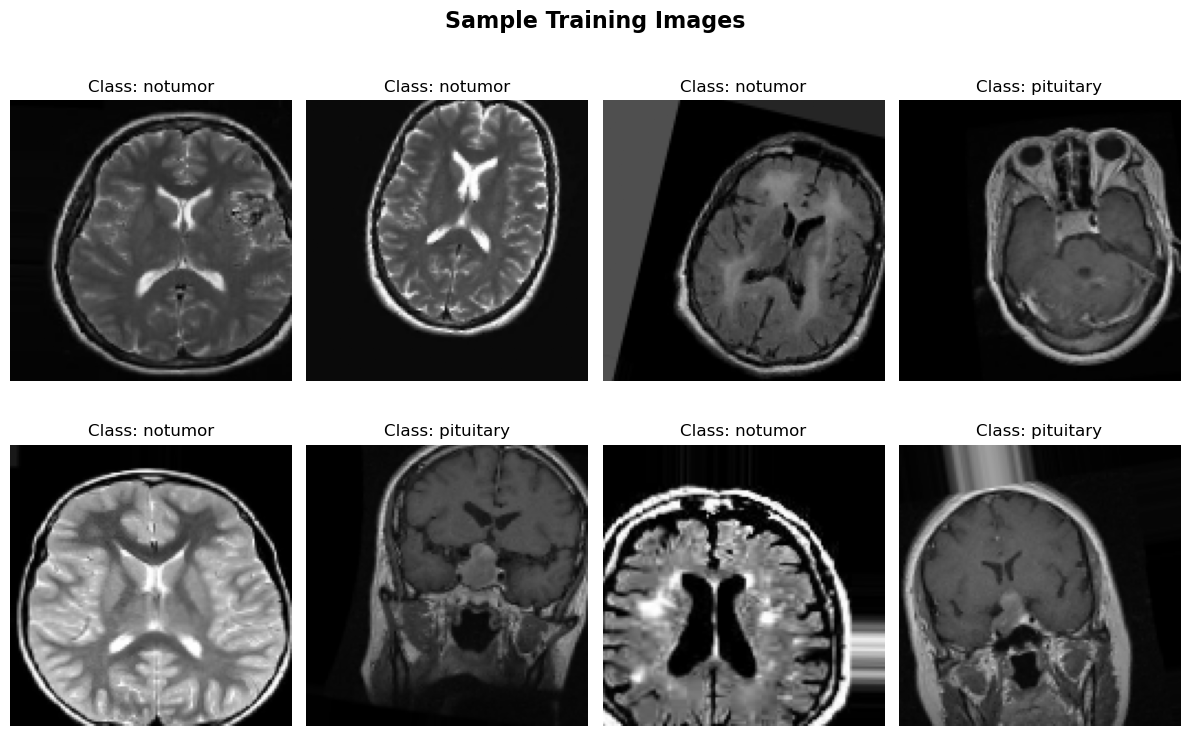

In [8]:
# visualize few sample
import numpy as np
import matplotlib.pyplot as plt

# Show a few random samples from the training set
sample_batch, sample_labels = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(8):  # show 8 samples
    plt.subplot(2, 4, i+1)
    plt.imshow(sample_batch[i])
    plt.title(f"Class: {list(train_generator.class_indices.keys())[np.argmax(sample_labels[i])]}")
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Build the model (CNN)

In [9]:
# build the model 
def build_memory_efficient_model(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                 num_classes=NUM_CLASSES,
                                 model_type='mobilenet'):
    #load CNN transfer learning
    if model_type == 'mobilenet':
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
        model_name = "MobileNetV2"
    elif model_type == 'efficientnet':
        base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
        model_name = "EfficientNetB0"
    else:
        raise ValueError("model_type must be 'mobilenet' or 'efficientnet'")
   
    #feature extraction mode.
    base_model.trainable = False # freeze base model
# - Prevents MobileNet/EfficientNet weights from changing.
# Saves memory and training time.
#  Only your custom layers will train.

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(), # converts feature maps into a single vector
        Dense(256, activation='relu'), # first fully connected layer, learns high level patterns for classification
        Dropout(0.5), #random drops of neurons during training
        Dense(128, activation='relu'), # sec layer
        Dropout(0.3), # more regular
        Dense(num_classes, activation='softmax', dtype='float32') # final output layer, produces prob for each tumor class
    ], name=f'{model_name}_BrainTumor')

    return model, model_name
#build and compile the model
model, model_name = build_memory_efficient_model(model_type='mobilenet')
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
# some callbacks bout the GPU
import numpy as np 

class MemoryCleanupCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        keras.backend.clear_session()
        if epoch % 5 == 0:
            print(f"\n/ Memory cleanup performed (epoch {epoch})")

class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights_array))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    MemoryCleanupCallback()
]

In [11]:
# Train deep learning model
history = model.fit( #start the training process
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights, # balance kalau imbalanced
    callbacks=callbacks,
    verbose=1 # control how much info is printed during training
)

# history stores the training results(loss, accuracy per epoch)

Epoch 1/30


/ Memory cleanup performed (epoch 0)
572/572 ━━━━━━━━━━━━━━━━━━━━ 212s 358ms/step - accuracy: 0.6508 - loss: 0.8538 - val_accuracy: 0.7274 - val_loss: 0.7557 - learning_rate: 1.0000e-04
Epoch 2/30
572/572 ━━━━━━━━━━━━━━━━━━━━ 221s 384ms/step - accuracy: 0.8239 - loss: 0.5060 - val_accuracy: 0.7458 - val_loss: 0.7328 - learning_rate: 1.0000e-04
Epoch 3/30
572/572 ━━━━━━━━━━━━━━━━━━━━ 209s 364ms/step - accuracy: 0.8530 - loss: 0.4172 - val_accuracy: 0.7642 - val_loss: 0.6395 - learning_rate: 1.0000e-04
Epoch 4/30
572/572 ━━━━━━━━━━━━━━━━━━━━ 218s 379ms/step - accuracy: 0.8690 - loss: 0.3755 - val_accuracy: 0.7660 - val_loss: 0.6438 - learning_rate: 1.0000e-04
Epoch 5/30
572/572 ━━━━━━━━━━━━━━━━━━━━ 209s 364ms/step - accuracy: 0.8738 - loss: 0.3512 - val_accuracy: 0.7932 - val_loss: 0.5859 - learning_rate: 1.0000e-04
Epoch 6/30
572/572 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.8894 - loss: 0.3171  
/ Memory cleanup performed (epoch 5)
572/572 ━━━━━━━━━━━━━━━━━━━━ 230s 

# Evaluation

In [12]:
# Evaluation
print("\n" + "="*70)
print("EVALUATION ON TEST SET")
print("="*70)

test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes


EVALUATION ON TEST SET
164/164 ━━━━━━━━━━━━━━━━━━━━ 59s 351ms/step


# Summary of accuracy and loss plot

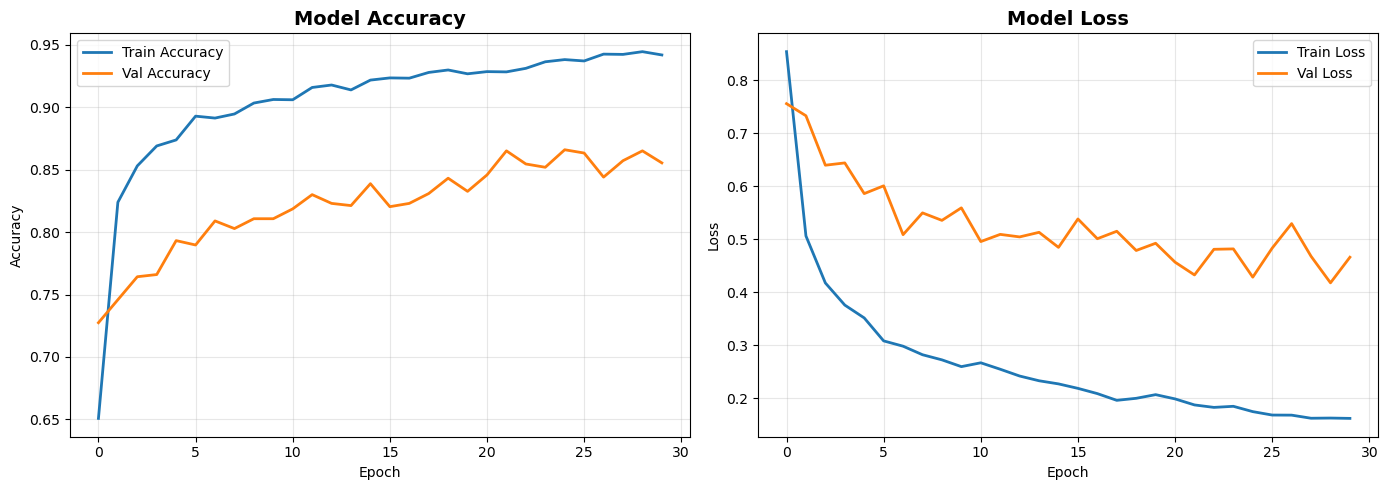

In [13]:
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
labels = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print("="*70)
report = classification_report(y_true, y_pred, target_names=labels, digits=4)
print(report)


Classification Report:
              precision    recall  f1-score   support

      glioma     0.8746    0.8833    0.8789       300
  meningioma     0.8731    0.5621    0.6839       306
     notumor     0.9136    0.9654    0.9388       405
   pituitary     0.7702    0.9833    0.8638       300

    accuracy                         0.8566      1311
   macro avg     0.8579    0.8485    0.8414      1311
weighted avg     0.8624    0.8566    0.8484      1311



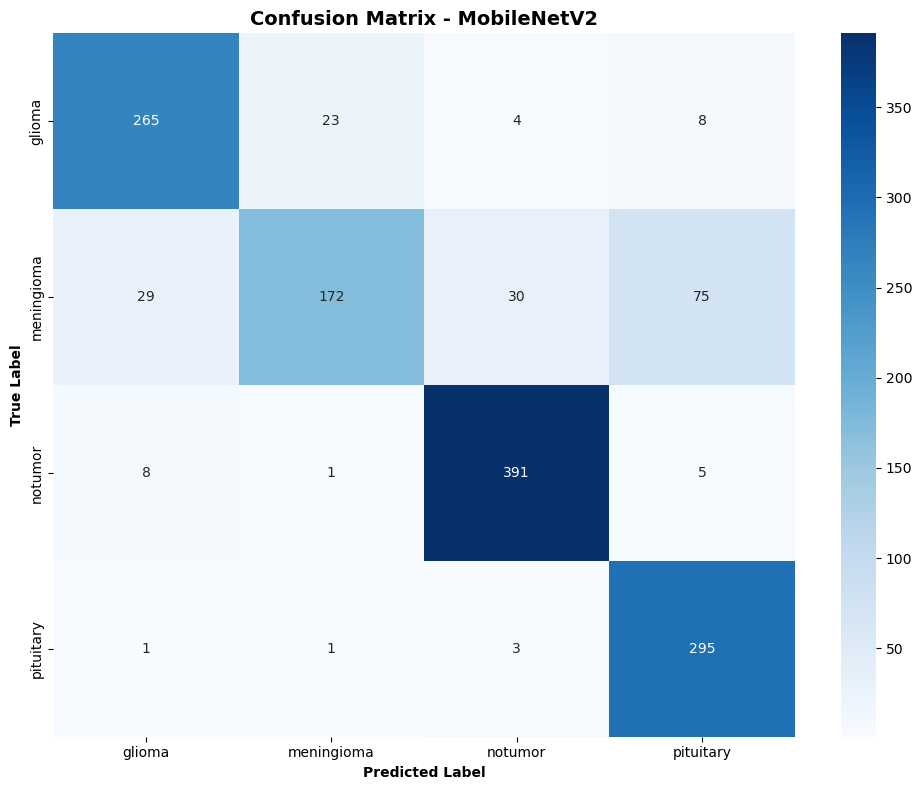

In [15]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [17]:
cm = confusion_matrix(y_true, y_pred)

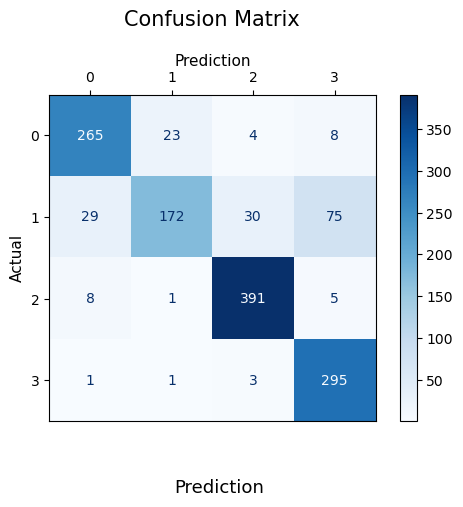

In [18]:
cm = confusion_matrix(y_true, y_pred,)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.show()

In [19]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88       300
           1       0.87      0.56      0.68       306
           2       0.91      0.97      0.94       405
           3       0.77      0.98      0.86       300

    accuracy                           0.86      1311
   macro avg       0.86      0.85      0.84      1311
weighted avg       0.86      0.86      0.85      1311



In [20]:
#Accuracy vs Baseline
model_accuracy = accuracy_score(y_true, y_pred)
random_accuracy = 1.0 / NUM_CLASSES
print("\nModel Accuracy: {:.4f} ({:.2f}%)".format(model_accuracy, model_accuracy*100))
print("Random Baseline: {:.4f} ({:.2f}%)".format(random_accuracy, random_accuracy*100))
print("Improvement: {:.2f}%".format((model_accuracy-random_accuracy)*100))


Model Accuracy: 0.8566 (85.66%)
Random Baseline: 0.2500 (25.00%)
Improvement: 60.66%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


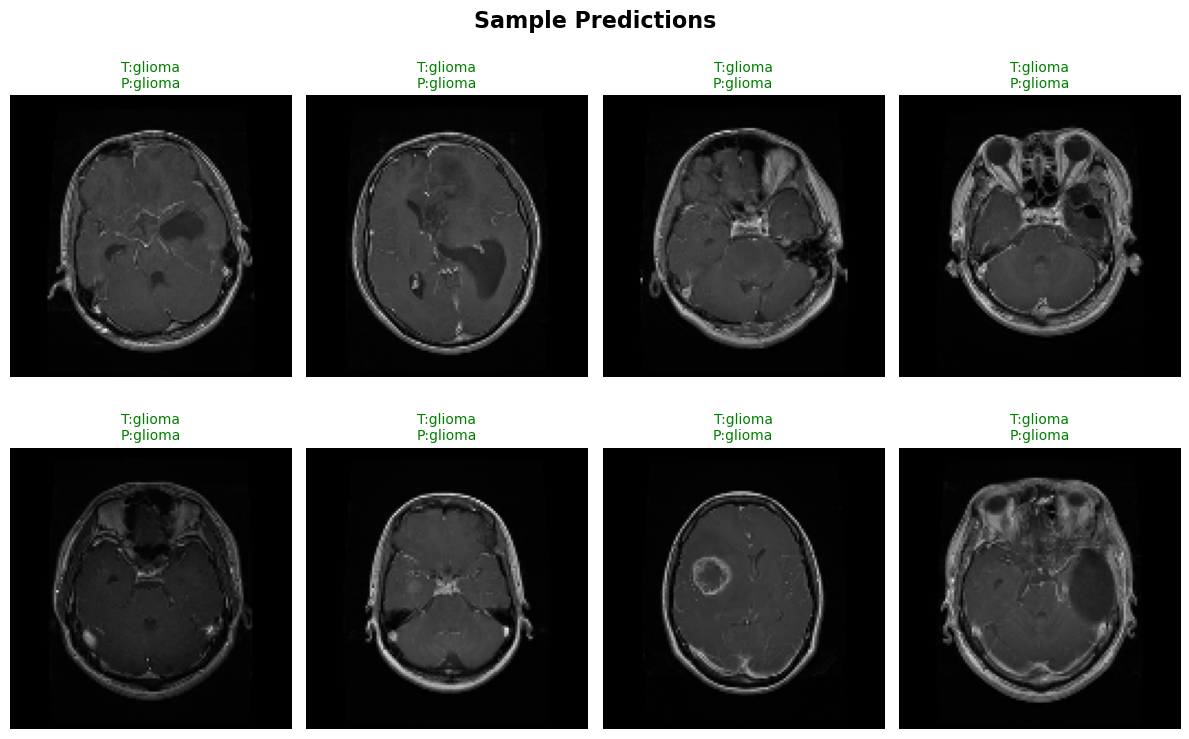

In [22]:
# testing testing
test_batch, test_labels = next(test_generator)

plt.figure(figsize=(12, 8))
for i in range(8):  # show 8 test samples
    plt.subplot(2, 4, i+1)
    plt.imshow(test_batch[i])

    # True and predicted class
    true_class = labels[np.argmax(test_labels[i])]
    pred_class = labels[np.argmax(model.predict(test_batch[i][None, ...]))]

    # Color logic: green if correct, red if wrong
    color = "green" if true_class == pred_class else "red"

    plt.title(f"T:{true_class}\nP:{pred_class}", fontsize=10, color=color)
    plt.axis("off")

plt.suptitle("Sample Predictions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# 3d dataset 

In [6]:
!pip install nibabel

   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.3 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.3 MB 1.6 MB/s eta 0:00:02
   --------- ------------------------------ 0.8/3.3 MB 1.5 MB/s eta 0:00:02
   ------------ --------------------------- 1.0/3.3 MB 1.5 MB/s eta 0:00:02
   ------------ --------------------------- 1.0/3.3 MB 1.5 MB/s eta 0:00:02
   --------------- ------------------------ 1.3/3.3 MB 1.1 MB/s eta 0:00:02
   --------------- ------------------------ 1.3/3.3 MB 1.1 MB/s eta 0:00:02
   --------------- ------------------------ 1.3/3.3 MB 1.1 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.3 MB 827.8 kB/s eta 0:00:03
   ------------------- -------------------- 1.6/3.3 MB 827.8 kB/s eta 0:00:03
   ------------------- -------------------- 1.6/3.3 MB 827.8 kB/s eta 0:00:03
   ------------------- -------------------- 1.6/3.3 MB 827.8 kB/s eta 0:00:03
   ---------------

In [1]:
import zipfile
import os

zip_path = 'archive (3).zip'
extract_path = '3d_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [7]:
path = "3d_Training/BraTS20_Training_001_flair.nii"

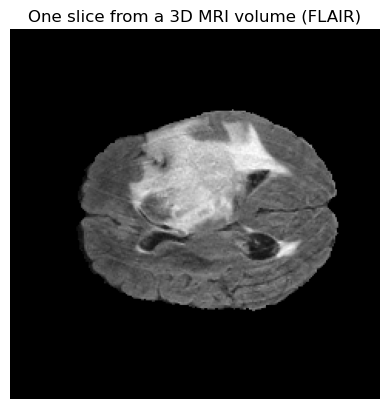

In [10]:
import nibabel as nib
import matplotlib.pyplot as plt

# Path to ONE sample
path = "3d_Training/BraTS20_Training_001_flair.nii"

# Load the 3D MRI volume
img = nib.load(path)
data = img.get_fdata()

# Pick a slice 
slice_idx = data.shape[2] // 2
slice_img = data[:, :, slice_idx]

plt.imshow(slice_img, cmap='gray')
plt.title("One slice from a 3D MRI volume (FLAIR)")
plt.axis('off')
plt.show()

In [2]:
import nibabel as nib
import matplotlib.pyplot as plt
import os

# Load the 3D MRI volume
path = "3d_Training/BraTS20_Training_001_flair.nii"
img = nib.load(path)
data = img.get_fdata()

print("Volume shape:", data.shape)

# Create output folder
os.makedirs("slices_output", exist_ok=True)

# Loop through each slice
for i in range(data.shape[2]):
    slice_img = data[:, :, i]

    plt.imshow(slice_img, cmap='gray')
    plt.title(f"Slice {i}")
    plt.axis('off')

    # Save each slice as an image
    plt.savefig(f"slices_output/slice_{i}.png", bbox_inches='tight', pad_inches=0)
    plt.close()

Volume shape: (240, 240, 155)


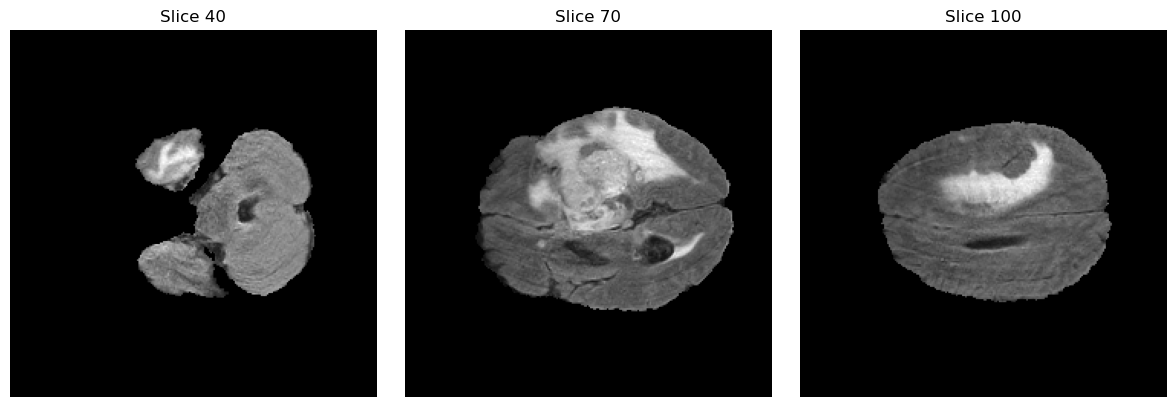

In [3]:
import nibabel as nib
import matplotlib.pyplot as plt

# Load the 3D MRI volume
path = "3d_Training/BraTS20_Training_001_flair.nii"
img = nib.load(path)
data = img.get_fdata()

# Choose slice indices you want to visualize
slice_indices = [40, 70, 100]

plt.figure(figsize=(12, 4))

for i, idx in enumerate(slice_indices):
    plt.subplot(1, 3, i+1)
    plt.imshow(data[:, :, idx], cmap='gray')
    plt.title(f"Slice {idx}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout

def build_3d_cnn(input_shape=(128, 128, 64, 1), num_classes=4):
    model = Sequential([
        Conv3D(32, (3,3,3), activation='relu', padding='same', input_shape=input_shape),
        MaxPooling3D((2,2,2)),

        Conv3D(64, (3,3,3), activation='relu', padding='same'),
        MaxPooling3D((2,2,2)),

        Conv3D(128, (3,3,3), activation='relu', padding='same'),
        MaxPooling3D((2,2,2)),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model